If I were to study the conversation usage patterns, what would I be looking for?

- are people chatting with those they trade with?
    - do they start chatting before or after they are trading?
        - does group size matter?
    - do stronger connections also have more messages sent?
        - compare intensity of positive influence to number (proportion?) of messages sent in the (previous?) round 
    - are individuals with stronger connections than the rest of the group likely to have sub group chats?
        - at what point do they break off if so?
- are people chatting with those they attack with?
    - does the intensity of the attack mean anything?
- mental load
    - [x] how many chats does each person have?
    - how fast do they respond?
    - how often/fast do they switch between each conversation?

In [4]:
import json

def pull_chat_data_from_json(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)

        chat_data = {}

        for game_id, game_data in data.items():
            if 'chatInfo' in game_data:
                game_chat_data = game_data['chatInfo']
                chat_data[game_id] = game_chat_data
                
    return chat_data

chat_data = pull_chat_data_from_json('preprod_filtered.json')

No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.
No messages found for conversation -O8hQ7vc8y5ZrWDaWWX3. Skipping.


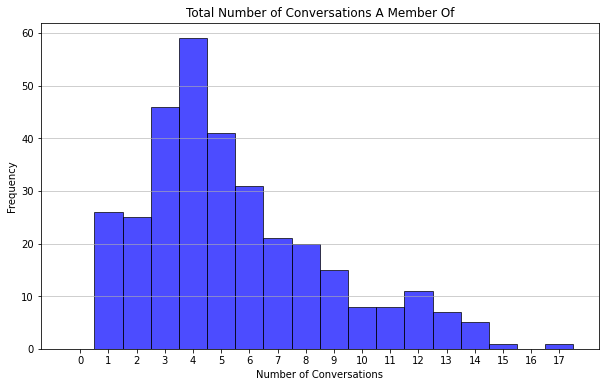

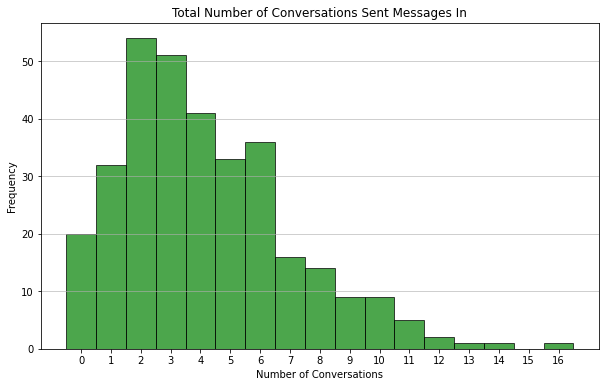

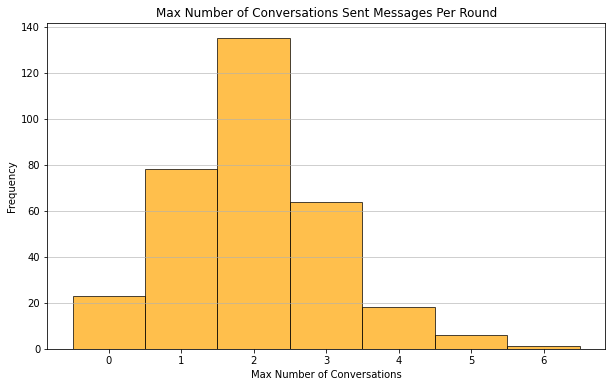

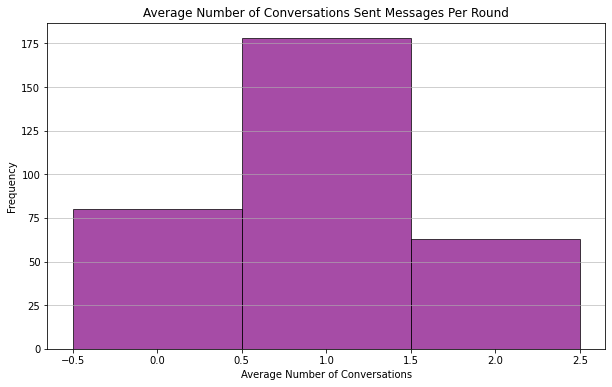

In [38]:
# How many chats are people a member of?
# How many chats do they send messages in total?
# How many chats do they send messages in per round?

def find_number_of_conversations_for_all_games(json_file):
    all_num_conversations_in = []
    all_num_conversations_sent_messages = []
    all_num_conversations_sent_messages_per_round = []
    all_avg_num_conversations_sent_messages_per_round = []
    all_max_num_conversations_sent_messages_per_round = []

    with open(json_file, 'r') as f:
        data = json.load(f)

        for game_id, game_data in data.items():
            players = game_data['privateInfo']['gameNames']

            chat_data = game_data['chatInfo']
            round_end_times = []
            for c_id, conversation in chat_data['conversations'].items():
                if c_id == 'global':
                    for m_id, message in conversation['messages'].items():
                        if message['runtimeType'] == 'gameNotification' or message['from'] == 'Game':
                            round_end_times.append(message['time'])
            if len(round_end_times) == 0:
                print(f"No round end times found for game {game_id}. Skipping.")
                continue

            for player in players:
                num_conversations_in, num_conversations_sent_messages, num_conversations_sent_messages_per_round = find_number_of_conversations_for_player(chat_data, player, round_end_times)
                all_num_conversations_in.append(num_conversations_in)
                all_num_conversations_sent_messages.append(num_conversations_sent_messages)
                all_num_conversations_sent_messages_per_round.append(num_conversations_sent_messages_per_round)
                all_avg_num_conversations_sent_messages_per_round.append(sum(num_conversations_sent_messages_per_round) / len(num_conversations_sent_messages_per_round))
                all_max_num_conversations_sent_messages_per_round.append(max(num_conversations_sent_messages_per_round))
        
        display_charts(all_num_conversations_in, all_num_conversations_sent_messages, all_num_conversations_sent_messages_per_round, all_max_num_conversations_sent_messages_per_round, all_avg_num_conversations_sent_messages_per_round)

def display_charts(all_num_conversations_in, all_num_conversations_sent_messages, all_num_conversations_sent_messages_per_round, all_max_num_conversations_sent_messages_per_round, all_avg_num_conversations_sent_messages_per_round):
    import matplotlib.pyplot as plt

    # Plot number of conversations in
    plt.figure(figsize=(10, 6))
    bins = [i - 0.5 for i in range(max(all_num_conversations_in) + 2)]
    plt.hist(all_num_conversations_in, bins=bins, alpha=0.7, color='blue', edgecolor='black')
    plt.xticks(range(max(all_num_conversations_in) + 1))
    plt.title('Total Number of Conversations A Member Of')
    plt.xlabel('Number of Conversations')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Plot number of conversations sent messages
    plt.figure(figsize=(10, 6))
    bins = [i - 0.5 for i in range(max(all_num_conversations_sent_messages) + 2)]
    plt.hist(all_num_conversations_sent_messages, bins=bins, alpha=0.7, color='green', edgecolor='black')
    plt.xticks(range(max(all_num_conversations_sent_messages) + 1))
    plt.title('Total Number of Conversations Sent Messages In')
    plt.xlabel('Number of Conversations')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Plot max number of conversations sent messages per round
    plt.figure(figsize=(10, 6))
    bins = [i - 0.5 for i in range(max(all_max_num_conversations_sent_messages_per_round) + 2)]
    plt.hist(
        all_max_num_conversations_sent_messages_per_round,
        bins=bins,
        alpha=0.7,
        color='orange',
        edgecolor='black'
    )
    plt.xticks(range(max(all_max_num_conversations_sent_messages_per_round) + 1))
    plt.title('Max Number of Conversations Sent Messages Per Round')
    plt.xlabel('Max Number of Conversations')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Plot average number of conversations sent messages per round
    plt.figure(figsize=(10, 6))
    bins = [i - 0.5 for i in range(int(max(all_avg_num_conversations_sent_messages_per_round)) + 2)]
    plt.hist(
        all_avg_num_conversations_sent_messages_per_round,
        bins=bins,
        alpha=0.7,
        color='purple',
        edgecolor='black'
    )
    plt.title('Average Number of Conversations Sent Messages Per Round')
    plt.xlabel('Average Number of Conversations')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()  

def find_number_of_conversations_for_player(chat_data, player_name, round_end_times):
    num_conversations_in = 0
    num_conversations_sent_messages = 0
    num_conversations_sent_messages_per_round = [0 for _ in range(len(round_end_times))]

    for c_id, conversation in chat_data['conversations'].items():
        if c_id == 'global' or player_name in conversation['participants']:
            num_conversations_in += 1

            if 'messages' not in conversation:
                print(f"No messages found for conversation {c_id}. Skipping.")
                break

            for m_id, message in conversation['messages'].items():
                if message.get('from') == player_name:
                    num_conversations_sent_messages += 1
                    break  # Count only once per conversation

            round = 1

            for m_id, message in conversation['messages'].items():
                if round > len(round_end_times):
                    break  # message sent after the last round, ignore
                if message['time'] >= round_end_times[round-1]:
                    round += 1
                    if round > len(round_end_times):
                        break  # message sent after the last round, ignore

                if message.get('from') == player_name:
                    if message['time'] < round_end_times[round-1] and (round == 1 or message['time'] > round_end_times[round-2]):
                        num_conversations_sent_messages_per_round[round - 1] += 1
                        round += 1

    return num_conversations_in, num_conversations_sent_messages, num_conversations_sent_messages_per_round
    
    
find_number_of_conversations_for_all_games('preprod_filtered.json')
    


In [ ]:

# How quickly do people respond to messages in conversations?
# How quickly do people send messages in any conversation?
# How quickly do people switch between conversations?
# How many times do they switch conversations in a round?

def find_number_of_conversations_for_all_games(json_file):
    all_avg_respond_time = []
    all_min_respond_time = []
    all_avg_message_time = []
    all_min_message_time = []
    all_avg_num_switches = []
    all_max_num_switches = []
    all_avg_switch_time = []
    all_min_switch_time = []

    with open(json_file, 'r') as f:
        data = json.load(f)

        for game_id, game_data in data.items():
            players = game_data['privateInfo']['gameNames']

            chat_data = game_data['chatInfo']
            round_end_times = []
            for c_id, conversation in chat_data['conversations'].items():
                if c_id == 'global':
                    for m_id, message in conversation['messages'].items():
                        if message['runtimeType'] == 'gameNotification' or message['from'] == 'Game':
                            round_end_times.append(message['time'])
            if len(round_end_times) == 0:
                print(f"No round end times found for game {game_id}. Skipping.")
                continue

            for player in players:
                avg_respond_time, min_respond_time, avg_message_time, min_message_time, avg_num_switches, max_num_switches, avg_switch_time, min_switch_time = find_conversation_timing_for_player(chat_data, player, round_end_times)
                all_avg_respond_time.append(avg_respond_time)
                all_min_respond_time.append(min_respond_time)
                all_avg_message_time.append(avg_message_time)
                all_min_message_time.append(min_message_time)
                all_avg_num_switches.append(avg_num_switches)
                all_max_num_switches.append(max_num_switches)
                all_avg_switch_time.append(avg_switch_time)
                all_min_switch_time.append(min_switch_time)
                
        
        display_charts(all_avg_respond_time, all_min_respond_time, all_avg_message_time, all_min_message_time, all_avg_num_switches, all_max_num_switches, all_avg_switch_time, all_min_switch_time)

def display_charts(all_avg_respond_time, all_min_respond_time, all_avg_message_time, all_min_message_time, all_avg_num_switches, all_max_num_switches, all_avg_switch_time, all_min_switch_time):
    # TODO
    pass

def find_conversation_timing_for_player(chat_data, player_name, round_end_times):
    respond_times = []
    message_times = []
    switch_times = []
    num_switches_per_round = [0 for _ in range(len(round_end_times))]

    for c_id, conversation in chat_data['conversations'].items():
        if c_id == 'global' or player_name in conversation['participants']:
            num_conversations_in += 1

            if 'messages' not in conversation:
                print(f"No messages found for conversation {c_id}. Skipping.")
                break

            round = 1

            for m_id, message in conversation['messages'].items():
                if round > len(round_end_times):
                    break  # message sent after the last round, ignore
                if message['time'] >= round_end_times[round-1]:
                    round += 1
                    if round > len(round_end_times):
                        break  # message sent after the last round, ignore

                if message.get('from') == player_name:
                    if message['time'] < round_end_times[round-1] and (round == 1 or message['time'] > round_end_times[round-2]):
                        num_conversations_sent_messages_per_round[round - 1] += 1
                        round += 1


    avg_respond_time = sum(respond_times) / len(respond_times) if respond_times else 0
    min_respond_time = min(respond_times) if respond_times else 0
    avg_message_time = sum(message_times) / len(message_times) if message_times else 0
    min_message_time = min(message_times) if message_times else 0
    avg_num_switches = sum(num_switches_per_round) / len(num_switches_per_round) if num_switches_per_round else 0
    max_num_switches = max(num_switches_per_round) if num_switches_per_round else 0
    avg_switch_time = sum(switch_times) / len(switch_times) if switch_times else 0
    min_switch_time = min(switch_times) if switch_times else 0

    return  avg_respond_time, min_respond_time, avg_message_time, min_message_time, avg_num_switches, max_num_switches, avg_switch_time, min_switch_time
    
    
find_number_of_conversations_for_all_games('preprod_filtered.json')
    
